<a href="https://colab.research.google.com/github/007arjungangwar/Programming-in-Python/blob/main/Decorator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
1. What is a Decorator?
A decorator is simply a function that wraps another function.

Think of it like:
“Add extra features to a function without touching its original code.”

```





```
2. Why Use Decorators?
Code reuse (avoid repetition)
Add logging, timing, authentication
Clean and readable code
Separate concerns (logic vs extra behavior)
```



Basic Example (Without Decorator)

In [ ]:
def greet():
    print("Hello World!")

greet()

Hello World!


In [ ]:
def wrapper():
    print("Before")
    greet()
    print("After")

wrapper()

Before
Hello World!
After


Converting to Decorator

In [ ]:
def my_decorator(func):
    def wrapper():
        print("Before")
        func()
        print("After")
    return wrapper

In [ ]:
dec_function_output = my_decorator(greet)
dec_function_output()

Before
Hello World!
After


In [ ]:
@my_decorator
def greet():
    print("Hello!")

greet()

Before
Hello!
After


# ***********************************

In [ ]:
def greet():
    print("Hello World!")

In [ ]:
def your_decorator(func):
    def wrapper():
        print("*"*10)
        func()
        print("*"*10)
    return wrapper

In [ ]:
output=your_decorator(greet)
output()

**********
Hello World!
**********


In [ ]:
@your_decorator
def greet():
    print("Hello World!")
greet()

**********
Hello World!
**********


In [ ]:
@my_decorator
def greet():
    print("Hello!")

greet()

How It Works Internally

In [ ]:
greet = my_decorator(greet)

Decorator with Arguments

In [ ]:
def my_decorator(func):
    def wrapper(name):
        print("Before")
        func(name)
        print("After")
    return wrapper

@my_decorator
def greet(name):
    print(f"Hello {name}")

greet("Arjun")

Using *args and **kwargs (Best Practice)

In [ ]:
def my_decorator(func):
    def wrapper(*args, **kwargs):
        print("Before")
        result = func(*args, **kwargs)
        print("After")
        return result
    return wrapper

Returning Values

In [ ]:
@my_decorator
def add(a, b):
    return a + b

print(add(2, 3))

Multiple Decorators

In [ ]:
def deco1(func):
    def wrapper():
        print("Deco1")
        func()
    return wrapper

def deco2(func):
    def wrapper():
        print("Deco2")
        func()
    return wrapper

@deco1
@deco2
def say_hi():
    print("Hi")

say_hi()

Decorator with Parameters

In [ ]:
def repeat(n):
    def decorator(func):
        def wrapper(*args, **kwargs):
            for _ in range(n):
                func(*args, **kwargs)
        return wrapper
    return decorator

@repeat(3)
def greet():
    print("Hello")

greet()

Built-in Decorators
1. @staticmethod



```
1. @staticmethod
🔹 Definition

A static method is a method that:

belongs to the class
does NOT access:
instance variables (self)
class variables (cls)

It behaves like a normal function but is placed inside a class for better organization.
```





```
A static method says:

“This function has NO relation with object or class.”

It is just kept inside the class for organization.
```



In [ ]:
class Student:
    @staticmethod
    def celsius_to_fahrenheit(c):
        return (c * 9/5) + 32

print(Student.celsius_to_fahrenheit(30))

86.0


In [ ]:
class MyClass:
    def hello(self):
        print("Hello")

In [ ]:
MyClass.hello()

TypeError: MyClass.hello() missing 1 required positional argument: 'self'

In [ ]:
class MyClass:
    @staticmethod
    def hello():
        print("World")

In [ ]:
MyClass.hello()

World


In [ ]:
class Calculator:
    @staticmethod
    def add(a, b):
        return a + b
print(Calculator.add(10, 20))

30


In [ ]:
class new(Calculator):
    def subtract(a, b):
        return a - b
print(new.add(10, 20))
print(new.subtract(10, 20))

30
-10


In [ ]:
class Temperature:

    @staticmethod
    def celsius_to_fahrenheit(c):
        return (c * 9/5) + 32



```
Use @staticmethod when:

“Method is logically related to class but does not need class/object data.”
```



2. @classmethod



```
2. @classmethod
🔹 Definition

A class method:
works with the class itself
takes cls as first parameter
can access class variables
```



In [ ]:
class Student:

    college = "IIT Palakkad"

    @classmethod
    def show_college(cls):
        print(Student.college)

Student.show_college()

IIT Palakkad


In [ ]:
class Student:
    college = "IIT Palakkad"
    def show_college():
        print(Student.college)

Student.show_college()

IIT Palakkad


In [ ]:
class Student:
    school = "MIT"
    venue="Chennai"
    @classmethod
    def show_school(cls):
        print(cls.school)

Student.show_school()

MIT


In [ ]:
Student.venue

'Chennai'

In [ ]:
class Student:

    def __init__(self, name):
        self.name = name

    @classmethod
    def from_string(cls, data):
        name = data.split("-")[0]
        return cls(name)

s = Student.from_string("Arjun-101")
print(s.name)

Arjun


3. @property



```
3. @property
🔹 Definition

@property allows a method to be accessed like an attribute.

It provides:

encapsulation
getter functionality
cleaner syntax
```



In [ ]:
class Student:
  def __init__(self, name, marks):
    self.name = name
    self.__marks = marks
  @property
  def marks(self):
    if self.__marks < 0:
      return "Negative Value not allowed"
    return self.__marks

In [ ]:
st1=Student("ABC",-90)

st1.name
st1.marks

'Negative Value not allowed'

In [ ]:
class Person:

    def get_name(self):
        return "Arjun"

p = Person()
print(p.get_name())

Arjun


In [ ]:
class Person:

    @property
    def name(self):
        return "Arjun"

p = Person()
print(p.name)

Arjun




```
Why Use @property?
Makes code cleaner
Protects data
Allows controlled access
```



In [ ]:
class Student:

    def __init__(self):
        self._marks = 0

    @property
    def marks(self):
        return self._marks

    @marks.setter
    def marks(self, value):
        if value < 0:
            print("Invalid Marks")
        else:
            self._marks = value

s = Student()
s.marks = 90
print(s.marks)

90


In [ ]:
class Person:
    def __init__(self, name):
        self._name = name

    @property
    def name(self):
        return self._name

Real-World Examples

Timing Decorator

In [ ]:
import time

def timer(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print("Time:", end - start)
        return result
    return wrapper

Authentication Decorator

In [ ]:
def authenticate(func):
    def wrapper(user):
        if user == "admin":
            return func(user)
        else:
            print("Access Denied")
    return wrapper

In [6]:
def import_module_demo():
    try:
        import geometry_2d.line
        print("Module imported successfully")
    except ModuleNotFoundError:
        print("Module not found. Please install geometry_2d package.")


# Function Call
import_module_demo()

Module not found. Please install geometry_2d package.


In [7]:
import numpy as np

def solve_linear_system():
    try:
        # Matrix A
        A = np.array([
            [1, -3, 3],
            [2, 3, -1],
            [4, -3, -1]
        ])

        # Matrix B
        B = np.array([-4, 15, 19])

        # Solve the system
        solution = np.linalg.solve(A, B)

        x, y, z = solution

        print("Solution:")
        print(f"x = {x:.2f}")
        print(f"y = {y:.2f}")
        print(f"z = {z:.2f}")

        # Verification
        print("\nVerification:")

        eq1 = x - 3*y + 3*z
        eq2 = 2*x + 3*y - z
        eq3 = 4*x - 3*y - z

        print(f"Equation 1: {eq1:.2f} = -4.00")
        print(f"Equation 2: {eq2:.2f} = 15.00")
        print(f"Equation 3: {eq3:.2f} = 19.00")

    except np.linalg.LinAlgError:
        print("Matrix is singular. No unique solution exists.")


# Function Call
solve_linear_system()

Solution:
x = 5.00
y = 1.00
z = -2.00

Verification:
Equation 1: -4.00 = -4.00
Equation 2: 15.00 = 15.00
Equation 3: 19.00 = 19.00


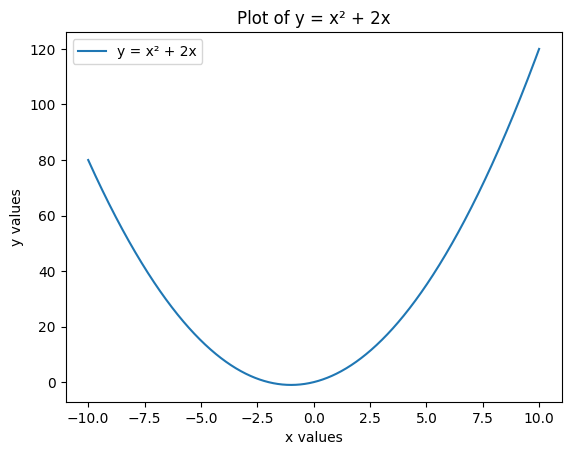

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def plot_quadratic():

    # 1000 values between -10 and 10
    x = np.linspace(-10, 10, 1000)

    # Equation
    y = x**2 + 2*x

    # Plot
    plt.plot(x, y, label="y = x² + 2x")

    # Title and labels
    plt.title("Plot of y = x² + 2x")
    plt.xlabel("x values")
    plt.ylabel("y values")

    # Legend
    plt.legend()

    # Show plot
    plt.show()


# Function Call
plot_quadratic()

In [ ]:
def find_anagrams(s, p):

    result = []
    p_sorted = sorted(p)

    for i in range(len(s) - len(p) + 1):
        part = s[i:i+len(p)]

        if sorted(part) == p_sorted:
            result.append(i)
    return result

# Example
print(find_anagrams("cbaebabacd", "abc"))
print(find_anagrams("abab", "ab"))
print(find_anagrams("hello", "ll"))

In [8]:
from collections import Counter

def find_anagrams(s: str, p: str) -> list:

    result = []

    p_count = Counter(p)
    window_count = Counter()

    k = len(p)

    for i in range(len(s)):

        window_count[s[i]] += 1

        # Remove left character
        if i >= k:
            if window_count[s[i-k]] == 1:
                del window_count[s[i-k]]
            else:
                window_count[s[i-k]] -= 1

        # Compare counters
        if window_count == p_count:
            result.append(i-k+1)

    return result


# Examples
print(find_anagrams("cbaebabacd", "abc"))
print(find_anagrams("abab", "ab"))
print(find_anagrams("hello", "ll"))

[0, 6]
[0, 1, 2]
[2]


In [1]:
with open('sample.txt', 'w') as file:
    text = file.write("Hello world! This is a sample text. Python is great. Hello again.")

In [7]:
with open('sample.txt', 'r') as file:
    text = file.read()

# Words
words = text.split()

In [9]:
text

'Hello world! This is a sample text. Python is great. Hello again.'

In [8]:
words

['Hello',
 'world!',
 'This',
 'is',
 'a',
 'sample',
 'text.',
 'Python',
 'is',
 'great.',
 'Hello',
 'again.']

In [10]:
# Sentences
sentences = re.split(r'[.!?]+', text)
sentences

['Hello world',
 ' This is a sample text',
 ' Python is great',
 ' Hello again',
 '']

In [11]:
len(sentences)

5

In [12]:
# Sentences
sentences = re.split(r'[.!?]+', text)
print(sentences)
print(len(sentences))

['Hello world', ' This is a sample text', ' Python is great', ' Hello again', '']
5


In [13]:
# Sentences
sentences = re.split(r'[.]+', text)
print(sentences)
print(len(sentences))

['Hello world! This is a sample text', ' Python is great', ' Hello again', '']
4


In [14]:
# Remove empty sentences
sentences = [s.strip() for s in sentences if s.strip()]
print(sentences)

['Hello world! This is a sample text', 'Python is great', 'Hello again']


In [17]:
# Word count
word_count = len(words)
print(words)
print(word_count)

# Sentence count
sentence_count = len(sentences)
print(sentences)
print(sentence_count)

# Longest word
longest_word = max(words, key=len)
print(words)
print(longest_word)

# Longest sentence
longest_sentence = max(sentences, key=len)
print(sentences)
print(longest_sentence)

['Hello', 'world!', 'This', 'is', 'a', 'sample', 'text.', 'Python', 'is', 'great.', 'Hello', 'again.']
12
['Hello world! This is a sample text', 'Python is great', 'Hello again']
3
['Hello', 'world!', 'This', 'is', 'a', 'sample', 'text.', 'Python', 'is', 'great.', 'Hello', 'again.']
world!
['Hello world! This is a sample text', 'Python is great', 'Hello again']
Hello world! This is a sample text


In [18]:
# Word frequency
word_frequency = {}

for word in words:
    word = word.strip(".,!?")
    word_frequency[word] = word_frequency.get(word, 0) + 1
print(word_frequency)

{'Hello': 2, 'world': 1, 'This': 1, 'is': 2, 'a': 1, 'sample': 1, 'text': 1, 'Python': 1, 'great': 1, 'again': 1}


In [23]:
# Vocabulary
print(word_frequency.keys())
print(set(word_frequency.keys()))
print(list(set(word_frequency.keys())))
vocabulary = sorted(list(set(word_frequency.keys())),reverse=True)
print(vocabulary)

dict_keys(['Hello', 'world', 'This', 'is', 'a', 'sample', 'text', 'Python', 'great', 'again'])
{'great', 'again', 'This', 'world', 'text', 'a', 'Hello', 'Python', 'is', 'sample'}
['great', 'again', 'This', 'world', 'text', 'a', 'Hello', 'Python', 'is', 'sample']
['world', 'text', 'sample', 'is', 'great', 'again', 'a', 'This', 'Python', 'Hello']


In [2]:
import re

def analyze_text_file(filename: str) -> dict:

    with open(filename, 'r') as file:
        text = file.read()

    # Words
    words = text.split()

    # Sentences
    sentences = re.split(r'[.!?]+', text)

    # Remove empty sentences
    sentences = [s.strip() for s in sentences if s.strip()]

    # Word count
    word_count = len(words)

    # Sentence count
    sentence_count = len(sentences)

    # Longest word
    longest_word = max(words, key=len)

    # Longest sentence
    longest_sentence = max(sentences, key=len)

    # Word frequency
    word_frequency = {}

    for word in words:
        word = word.strip(".,!?")
        word_frequency[word] = word_frequency.get(word, 0) + 1

    # Vocabulary
    vocabulary = sorted(list(set(word_frequency.keys())))

    return {
        "word_count": word_count,
        "sentence_count": sentence_count,
        "longest_word": longest_word,
        "longest_sentence": longest_sentence,
        "word_frequency": word_frequency,
        "vocabulary": vocabulary
    }


# Function Call
result = analyze_text_file("sample.txt")

for key, value in result.items():
    print(f"{key}: {value}")

word_count: 12
sentence_count: 4
longest_word: world!
longest_sentence: This is a sample text
word_frequency: {'Hello': 2, 'world': 1, 'This': 1, 'is': 2, 'a': 1, 'sample': 1, 'text': 1, 'Python': 1, 'great': 1, 'again': 1}
vocabulary: ['Hello', 'Python', 'This', 'a', 'again', 'great', 'is', 'sample', 'text', 'world']


In [34]:
import json

data = {
    "students": [
        {"name": "Arjun", "subjects": {"Math": 85, "Science": 90, "English": 88}},
        {"name": "Priya", "subjects": {"Math": 95, "Science": 92, "English": 91}},
        {"name": "Rahul", "subjects": {"Math": 78, "Science": 85, "English": 80}}
    ]
}

with open('students_subjects.json', 'w') as file:
    json.dump(data, file, indent=4)

In [35]:
with open('students_subjects.json', 'r') as file:
    data = json.load(file)

students = data["students"]
students

[{'name': 'Arjun', 'subjects': {'Math': 85, 'Science': 90, 'English': 88}},
 {'name': 'Priya', 'subjects': {'Math': 95, 'Science': 92, 'English': 91}},
 {'name': 'Rahul', 'subjects': {'Math': 78, 'Science': 85, 'English': 80}}]

In [36]:
for student in students:
    total = sum(student["subjects"].values())
    print(f"{student['name']}: {total}")
print(total)

Arjun: 263
Priya: 278
Rahul: 243
243


In [29]:
# Overall topper
totals = []

for student in students:
    total = sum(student["subjects"].values())
    totals.append({
        "name": student["name"],
        "total": total
    })
max_total = max(t["total"] for t in totals)
overall_topper = [t for t in totals if t["total"] == max_total]

In [37]:
print(totals)
print(max_total)
print(overall_topper)

[{'name': 'Arjun', 'total': 263}, {'name': 'Priya', 'total': 278}, {'name': 'Rahul', 'total': 243}]
278
[{'name': 'Priya', 'total': 278}]


In [38]:
students

[{'name': 'Arjun', 'subjects': {'Math': 85, 'Science': 90, 'English': 88}},
 {'name': 'Priya', 'subjects': {'Math': 95, 'Science': 92, 'English': 91}},
 {'name': 'Rahul', 'subjects': {'Math': 78, 'Science': 85, 'English': 80}}]

In [40]:
# Subject-wise topper
all_subjects = set()

for student in students:
    all_subjects.update(student["subjects"].keys())

print(all_subjects)

{'English', 'Math', 'Science'}


In [32]:
# Subject-wise topper
all_subjects = set()

for student in students:
    all_subjects.update(student["subjects"].keys())

subject_toppers = {}
for subject in all_subjects:
    max_marks = max(
        student["subjects"].get(subject, 0)
        for student in students)
    toppers = []
    for student in students:
        if student["subjects"].get(subject, 0) == max_marks:
            toppers.append({
                "name": student["name"],
                "marks": max_marks})

    subject_toppers[subject] = toppers

In [33]:
print(all_subjects)
print(subject_toppers)

{'English', 'Math', 'Science'}
{'English': [{'name': 'Priya', 'marks': 91}], 'Math': [{'name': 'Priya', 'marks': 95}], 'Science': [{'name': 'Priya', 'marks': 92}]}


In [20]:
import json

def subject_analysis(filename: str) -> dict:
    with open(filename, 'r') as file:
        data = json.load(file)
    students = data["students"]

    # Overall topper
    totals = []
    for student in students:
        total = sum(student["subjects"].values())
        totals.append({
            "name": student["name"],
            "total": total
        })
    max_total = max(t["total"] for t in totals)
    overall_topper = [
        t for t in totals if t["total"] == max_total]

    # Subject-wise topper
    all_subjects = set()

    for student in students:
        all_subjects.update(student["subjects"].keys())

    subject_toppers = {}

    for subject in all_subjects:

        max_marks = max(
            student["subjects"].get(subject, 0)
            for student in students)

        toppers = []
        for student in students:
            if student["subjects"].get(subject, 0) == max_marks:
                toppers.append({
                    "name": student["name"],
                    "marks": max_marks})
        subject_toppers[subject] = toppers

    return {
        "overall_topper": overall_topper,
        "subject_toppers": subject_toppers}

# Function Call
result = subject_analysis("students_subjects.json")

print(result)

{'overall_topper': [{'name': 'Priya', 'total': 278}], 'subject_toppers': {'English': [{'name': 'Priya', 'marks': 91}], 'Science': [{'name': 'Priya', 'marks': 92}], 'Math': [{'name': 'Priya', 'marks': 95}]}}
